In [1]:
from decimal import Decimal, getcontext

from pandas import value_counts

getcontext().prec = 105

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator

import collections


In [2]:
def digits_base(n: Decimal, base: int):
    """Возвращает список цифр числа n в системе счисления base и позицию десятичной точки. Ответ даёт точность 100 знаков после запятой."""
    digits = []
    integer = int(n)
    if integer == 0:
        digits.append(0)
    else:
        int_digits = []
        while integer > 0:
            int_digits.append(integer % base)
            integer //= base
        digits.extend(reversed(int_digits))

    point = len(digits)

    fractional = n - Decimal(int(n))

    for _ in range(100):
        fractional *= base
        digit = int(fractional)
        digits.append(digit)
        fractional -= Decimal(digit)

    return digits, point


d = Decimal('23.54')
digits, point = digits_base(d, 10)
s = ''.join(str(x) for x in digits[:point]) + (
    '.' + ''.join(str(x) for x in digits[point:]) if len(digits) > point else '')
print(s)
digits, point = digits_base(d, 3)
s = ''.join(str(x) for x in digits[:point]) + (
    '.' + ''.join(str(x) for x in digits[point:]) if len(digits) > point else '')
print(s)

print('---')

d = Decimal('4.444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444')
digits, point = digits_base(d, 10)
s = ''.join(str(x) for x in digits[:point]) + (
    '.' + ''.join(str(x) for x in digits[point:]) if len(digits) > point else '')
print(s)
digits, point = digits_base(d, 3)
s = ''.join(str(x) for x in digits[:point]) + (
    '.' + ''.join(str(x) for x in digits[point:]) if len(digits) > point else '')
print(s)


23.5400000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000
212.1121201222110102100011212012221101021000112120122211010210001121201222110102100011212012221101021000
---
4.4444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444
11.1022222222222222222222222222222222222222222222222222222222222222222222222222222222222222222222222222


In [3]:
def is_non_increasing(seq):
    """Проверяет, является ли последовательность невозрастающей."""
    for i in range(1, len(seq)):
        if seq[i] > seq[i - 1]:
            return False
    return True


def is_non_decreasing(seq):
    """Проверяет, является ли последовательность неубывающей."""
    for i in range(1, len(seq)):
        if seq[i] < seq[i - 1]:
            return False
    return True


In [4]:
def f_andrew(x, debug=False):
    if not isinstance(x, Decimal):
        x = Decimal(str(x))

    digits3, point3 = digits_base(x, 3)
    digits10, point10 = digits_base(x, 10)

    # минимальный знак в троичной записи, если в троичной записи число - невозрастающая последовательность
    if is_non_increasing(digits3):
        if debug:
            print(digits3)
            print("троичная невозрастающая")
        return digits3[-1]

    # максимальный знак в десятичной записи, если в десятичной записи число - неубывающая последовательность
    if is_non_decreasing(digits10):
        if debug:
            print(digits10)
            print("десятичная неубывающая")
        return digits10[0]

    # десятая цифра после запятой в десятичной записи, иначе
    if debug:
        print(digits10)
        print("иначе")
    return digits10[point10 + 9]


for digit in [2.0, 3.0, 3.5, 4.4, 4.5,
              Decimal(
                  '4.4444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444')]:
    print(f"Значение функции f_andrew для числа {digit}: {f_andrew(digit, True)}\n")


[2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
троичная невозрастающая
Значение функции f_andrew для числа 2.0: 0

[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
троичная невозрастающая
Значение функции f_andrew для числа 3.0: 0

[3, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

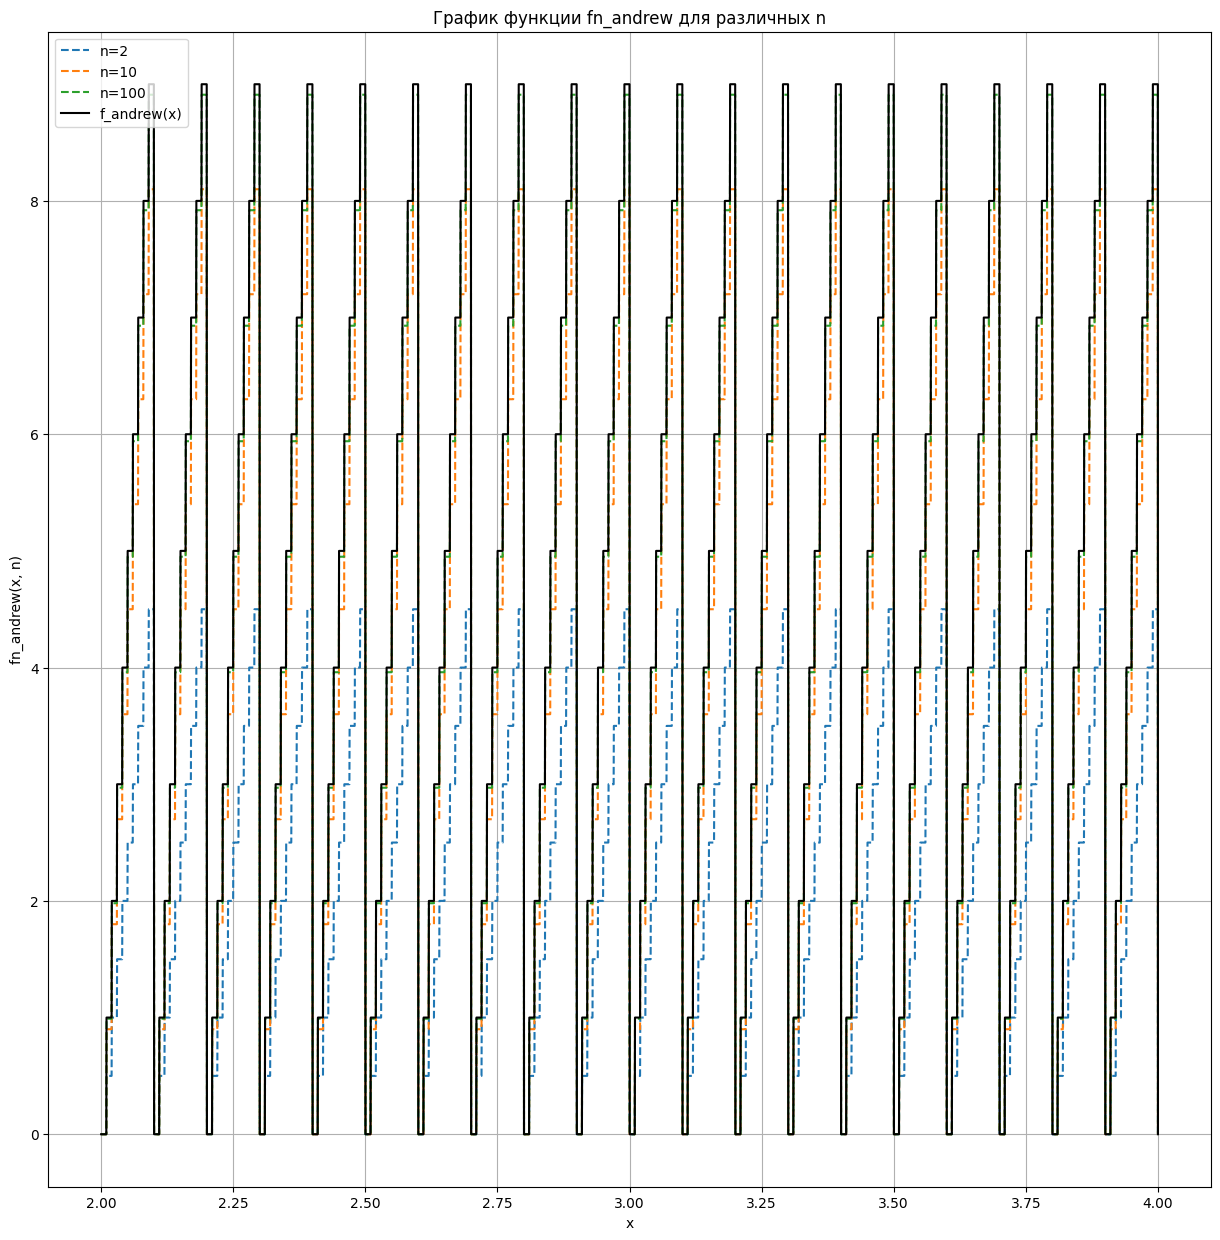

In [5]:
def fn_andrew(x, n):
    return (1 - 1 / n) * f_andrew(x)


digits = np.linspace(2, 4, 10000)
plt.figure(figsize=(15, 15))
for n in [2, 10, 100]:
    values = [fn_andrew(x, n) for x in digits]
    plt.plot(digits, values, linestyle='--', label=f"n={n}")
plt.plot(digits, [f_andrew(x) for x in digits], label='f_andrew(x)', color='black')
plt.title('График функции fn_andrew для различных n')
plt.xlabel('x')
plt.ylabel('fn_andrew(x, n)')
plt.legend()
plt.grid()
plt.show()

# Графики функции $f_n$ для различных $n$ приближаются к графику функции $f$ при увеличении $n$, но остаются ниже него, что соответствует условию $f_n \le f$.

In [6]:
def lebesgue_integral(a, b, n, step=Decimal('0.0001')):
    """Вычисляет приближённое значение интеграла Лебега функции fn_andrew на отрезке [a, b] с помощью словаря."""
    if not isinstance(a, Decimal):
        a = Decimal(str(a))
    if not isinstance(b, Decimal):
        b = Decimal(str(b))

    x = a
    value_counts = collections.defaultdict(int)
    while x < b:
        fn_value = fn_andrew(x, n)
        value_counts[fn_value] += 1
        x += step
    integral_sum = Decimal(0)
    for fn_value, count in value_counts.items():
        integral_sum += Decimal(fn_value) * Decimal(count) * step
    return integral_sum, value_counts


for n in [2, 10, 100]:
    integral_value, value_counts = lebesgue_integral(Decimal('2'), Decimal('4'), n)
    print(f"Значение интеграла Лебега функции fn_andrew при n={n}: {integral_value}")
    print(f"Распределение значений функции fn_andrew при n={n}:")
    for fn_value, count in sorted(value_counts.items()):
        print(f"Значение {fn_value}: встречается {count} раз")


Значение интеграла Лебега функции fn_andrew при n=2: 0.00005
Распределение значений функции fn_andrew при n=2:
Значение 0.0: встречается 19999 раз
Значение 0.5: встречается 1 раз
Значение интеграла Лебега функции fn_andrew при n=10: 0.000090000000000000002220446049250313080847263336181640625
Распределение значений функции fn_andrew при n=10:
Значение 0.0: встречается 19999 раз
Значение 0.9: встречается 1 раз
Значение интеграла Лебега функции fn_andrew при n=100: 0.00009899999999999999911182158029987476766109466552734375
Распределение значений функции fn_andrew при n=100:
Значение 0.0: встречается 19999 раз
Значение 0.99: встречается 1 раз


# Вывод о вычислительной сложности интегрирования функции $f$

## 1. Поведение интегралов $f_n$

Несмотря на рост $n$, интегралы остаются крайне малыми, увеличиваясь лишь не значительно, что не влияет на правильность значения. При этом эти значения являются погрешностями численного интегрирования, так как в эти значения состоят из суммы значений функции в случаях невозрастающей троичной записи. Но множество таких случаев на самом деле имеет меру ноль.

## 2. Почему $f_n$ не дают нормального приближения интеграла

1. Значения функции $f(x)$ определяются на масштабе порядка $10^{-10}$.
2. Для корректного численного интегрирования требуется рассмотреть все интервалы длины $10^{-10}$ на отрезке $[2,4]$.
3. Это означает необходимость обработки порядка
   $2 \cdot 10^{10}$
   различных значений аргумента.
4. Так как каждое значение функции требует анализа порядка $10^2$ цифр в двух системах счисления, общее количество операций становится порядка
   $2 \cdot 10^{12}$.
5. Это количество операций выходит за рамки практической вычислимости на стандартном оборудовании.

## 3. Почему нельзя приближать интеграла другими $f_n$

1. Интеграл функции $f$ можно было бы приближать функциями $f_n$, которые бы обрезали n первых цифр в записях числа в системах счисления.
*  1. Однако, всё равно нормальное приближение интеграла потребовало бы n > 10, чтобы захватить все значимые цифры.
    2. Это снова приводит к необходимости обработки порядка $10^{12}$ операций, что остаётся непрактичным.
* 1. Также по условию задачи требовалось то, что $f_n \le f$, что сделало бы невозможным или неэффективным использование приближения с обрезанием цифр для троичной записи. Так как минимальная цифра на обрезанной записи могла бы быть больше, чем минимальная цифра на полной записи, что нарушает условие $f_n \le f$.
    2. Это привело бы к таким же вычислительным сложностям, как и в исходном случае.

## 4. Итог

Таким образом, вычислительная сложность интегрирования функции $f$ остаётся чрезвычайно высокой из-за необходимости точного анализа большого количества цифр в различных системах счисления для каждого значения аргумента на отрезке интегрирования. Это делает практическое вычисление интеграла невозможным с использованием стандартных численных методов.

Однако можно воспользоваться методом Монте-Карло для получения значения, хоть и не по определению.


In [7]:
def monte_carlo_integration(a, b, n, num_samples=10000):
    """Оценивает интеграл Лебега функции f_andrew на отрезке [a, b] методом Монте-Карло."""
    if not isinstance(a, Decimal):
        a = Decimal(str(a))
    if not isinstance(b, Decimal):
        b = Decimal(str(b))

    value_counts = collections.defaultdict(int)
    for _ in range(num_samples):
        x = Decimal(str(np.random.uniform(float(a), float(b))))
        fn_value = fn_andrew(x, n)
        value_counts[fn_value] += 1
    integral_sum = Decimal(0)
    for fn_value, count in value_counts.items():
        integral_sum += Decimal(fn_value) * Decimal(count) * (b - a) / Decimal(num_samples)
    return integral_sum, value_counts


for n in [2, 10, 100]:
    integral_value, value_counts = monte_carlo_integration(Decimal('2'), Decimal('4'), n)
    print(f"Значение интеграла Лебега функции fn_andrew методом Монте-Карло при n={n}: {integral_value}")
    print(f"Распределение значений функции fn_andrew при n={n}:")
    for fn_value, count in sorted(value_counts.items()):
        print(f"Значение {fn_value}: встречается {count} раз")


Значение интеграла Лебега функции fn_andrew методом Монте-Карло при n=2: 4.5165
Распределение значений функции fn_andrew при n=2:
Значение 0.0: встречается 994 раз
Значение 0.5: встречается 976 раз
Значение 1.0: встречается 1006 раз
Значение 1.5: встречается 990 раз
Значение 2.0: встречается 983 раз
Значение 2.5: встречается 1024 раз
Значение 3.0: встречается 1023 раз
Значение 3.5: встречается 1015 раз
Значение 4.0: встречается 989 раз
Значение 4.5: встречается 1000 раз
Значение интеграла Лебега функции fn_andrew методом Монте-Карло при n=10: 8.07444000000000006698197552168494439683854579925537109375
Распределение значений функции fn_andrew при n=10:
Значение 0.0: встречается 995 раз
Значение 0.9: встречается 1023 раз
Значение 1.8: встречается 1030 раз
Значение 2.7: встречается 951 раз
Значение 3.6: встречается 1000 раз
Значение 4.5: встречается 1024 раз
Значение 5.4: встречается 1003 раз
Значение 6.3: встречается 991 раз
Значение 7.2: встречается 1000 раз
Значение 8.1: встречается 983

# Значение полученное методом Монте-Карло приближается к 9 - аналитическому значению интеграла Лебега функции.

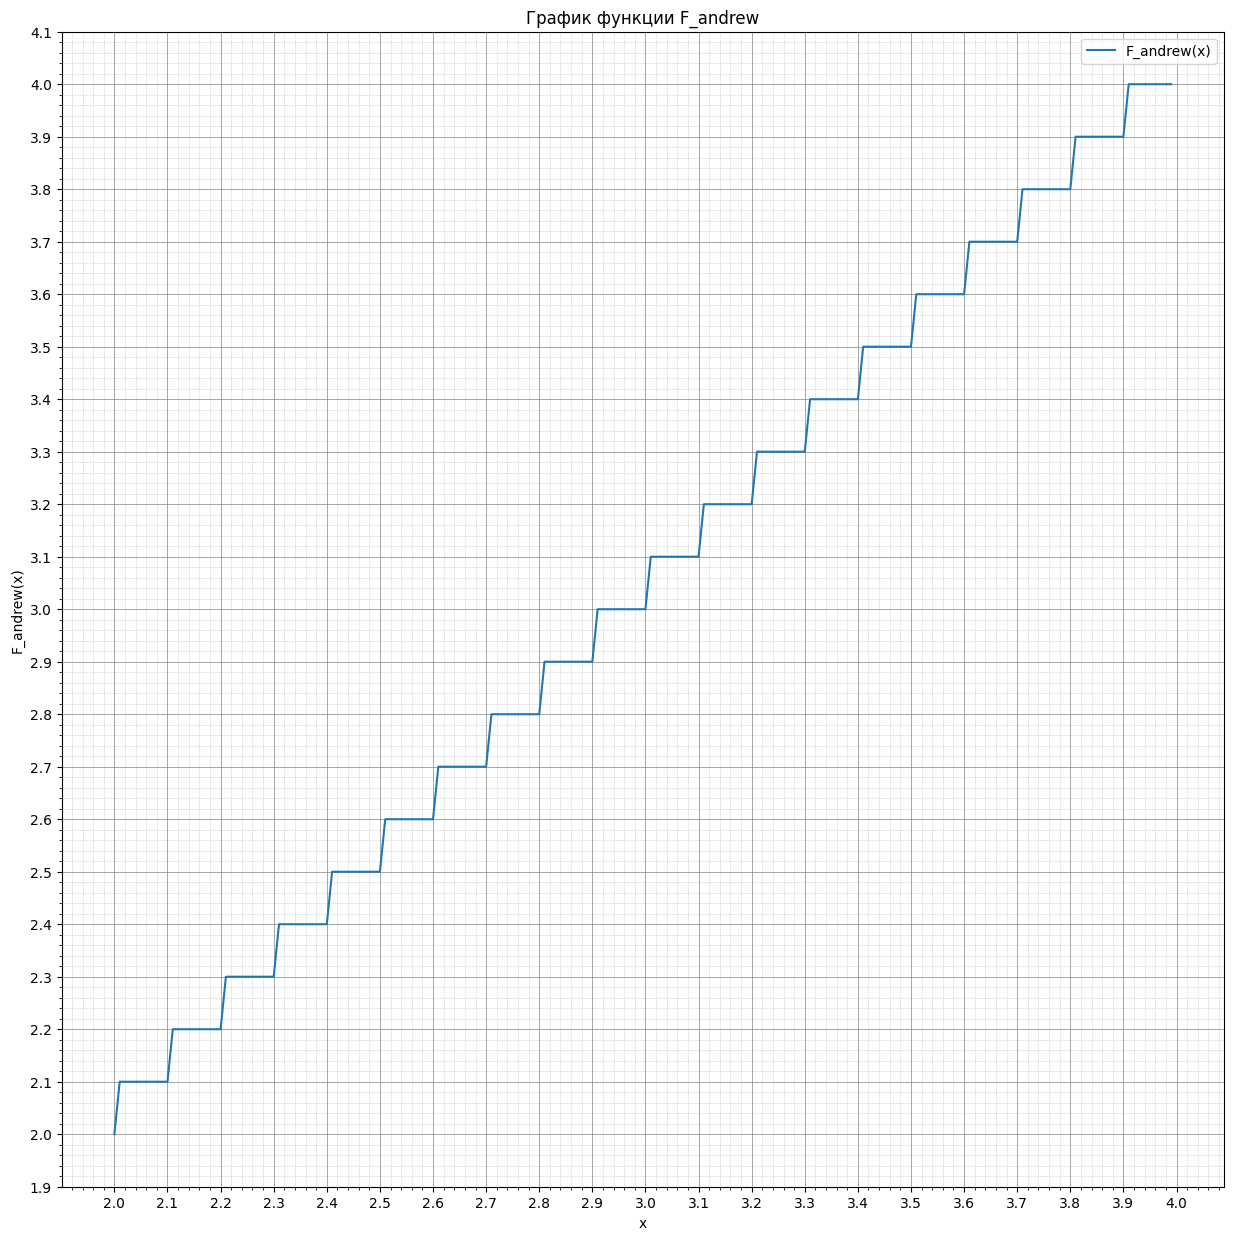

In [10]:
def F_andrew(x):
    if not isinstance(x, Decimal):
        x = Decimal(str(x))
    return (Decimal(10) * x).to_integral_value(rounding='ROUND_CEILING') / Decimal(10)


x_values = np.arange(2.0, 4.0, 0.01)
y_values = [F_andrew(x) for x in x_values]
plt.figure(figsize=(15, 15))
plt.plot(x_values, y_values, label='F_andrew(x)')
plt.title('График функции F_andrew')
plt.xlabel('x')
plt.ylabel('F_andrew(x)')
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(0.1))
ax.xaxis.set_minor_locator(MultipleLocator(0.01))
ax.yaxis.set_major_locator(MultipleLocator(0.1))
ax.yaxis.set_minor_locator(MultipleLocator(0.01))
plt.minorticks_on()
plt.grid(which='major', linestyle='-', linewidth=0.7, color='gray', alpha=0.7)
plt.grid(which='minor', linestyle='--', linewidth=0.4, color='gray', alpha=0.4)
plt.legend()
plt.show()


In [18]:
def lebesgue_stieltjes_integral(n):
    points = [k / 10 for k in range(20, 41)]
    jump = 0.1
    integral_sum = 0
    for x in points:
        integral_sum += fn_andrew(x, n) * jump
    return integral_sum


for n in [2, 10, 100, 1000, 10000]:
    integral_value = lebesgue_stieltjes_integral(n)
    print(f"Значение интеграла Лебега-Стилтьеса функции fn_andrew при n={n}: {integral_value}")


Значение интеграла Лебега-Стилтьеса функции fn_andrew при n=2: 0.05
Значение интеграла Лебега-Стилтьеса функции fn_andrew при n=10: 0.09000000000000001
Значение интеграла Лебега-Стилтьеса функции fn_andrew при n=100: 0.099
Значение интеграла Лебега-Стилтьеса функции fn_andrew при n=1000: 0.0999
Значение интеграла Лебега-Стилтьеса функции fn_andrew при n=10000: 0.09999000000000001


# Результат приближается к 0.1 - аналитическому значению интеграла Лебега-Стилтьеса функции